# NB104 - Sprint 0: instrument & confirm (NO training)

Implements Sprint 0 of `results/NEXT_STEPS_lane_head_strategy.md`. Produces four
numbers, with NO GPU training, that gate the rest of the plan:

| step | question | output |
|---|---|---|
| **S0.1** | Were the Bezier runs mis-scored by the decoder gating bug? | bezier curve-F1 (fixed decoder) vs polyline |
| **S0.2** | Is NB101's lane classifier threshold-able? | matched vs unmatched score histogram + separation |
| **S0.3** | How much of "always 8 lanes" is pure decode? | F1 / precision / recall / pred-count-corr vs tau |
| **S0.4** | Is the jaggedness really near-field? | near vs far mean-sq-2nd-diff (jaggedness) ratio |

**Prereqs on Drive:** `combined_aux_gca_full/best.pt` (NB101); optionally
`bezier_cubic_no_lcm/best.pt` + `bezier_lcm_gamma001/best.pt` (for S0.1);
val images via `bdd100k_clrkd_curve.tar` + GT via `bdd_complete_labels_70k.tar.gz`.

The decoder gating bug (S0.1) is **already fixed** in
`P7_validator/tools/lane_curve_f1.py` (`_decode_lane_bezier` no longer drops
predictions on `row[1] < 0.5`); this notebook measures the consequence.


### Cell 1: Mount + deps + locate repo/weights

In [1]:
import os, sys, subprocess
from pathlib import Path

os.environ['PYTHONIOENCODING'] = 'utf-8'

# --- Path constants FIRST (before anything that can fail), so later cells
#     always have FULL/DATASETS/MIG/CKPT defined even if a step below errors. ---
REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
MIG        = Path(REPO_ROOT)/'stage2/rmt_ppad_migration'
RMT        = MIG/'vendor/RMT-PPAD'
CKPT       = Path('/content/drive/MyDrive/EcoCAR/training_runs/checkpoints')
DATASETS   = Path('/content/drive/MyDrive/EcoCAR/datasets')
FULL       = Path('/content/bdd_dataset')
NB101_BEST = CKPT/'combined_aux_gca_full/best.pt'
BEZIER = {'bezier_cubic_no_lcm': CKPT/'bezier_cubic_no_lcm/best.pt',
          'bezier_lcm_gamma001': CKPT/'bezier_lcm_gamma001/best.pt'}

# --- Mount Drive + verify the FUSE mount is actually ALIVE. Colab's mount can
#     report success and then drop, giving OSError 107 "Transport endpoint is
#     not connected" on every later file access (incl. `import cv2`'s path
#     scan). Detect that here with a clear, actionable message. ---
def _drive_alive():
    try:
        return os.path.isdir('/content/drive/MyDrive')
    except OSError:
        return False

if not _drive_alive():
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True)   # force = recover a stale mount
    except Exception as _e:  # noqa: BLE001
        print('[mount] drive.mount raised:', _e)

if not _drive_alive():
    raise RuntimeError(
        'Google Drive mount is DEAD (OSError 107 "Transport endpoint is not '
        'connected"). This is a Colab runtime issue, NOT a notebook bug.\n'
        'FIX: Runtime -> Disconnect and delete runtime, then reconnect and '
        're-run from Cell 1. (The path constants above are already defined, so '
        'no NameError will cascade.)')

if not os.path.isdir(REPO_ROOT):
    raise FileNotFoundError(f'Missing {REPO_ROOT} -- verify Drive sync.')
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path: sys.path.insert(0, REPO_ROOT)

for _pkg in ('addict', 'yapf'):
    try: __import__(_pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install','-q',_pkg])
for _m in ('mmcv',):
    try: __import__(_m)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install','-q',_m])
try: import cv2  # noqa
except ImportError: subprocess.check_call([sys.executable,'-m','pip','install','-q','opencv-python-headless'])

print('[ok] Drive alive; NB101 best.pt:', NB101_BEST.exists())
for k,v in BEZIER.items(): print(f'   {k}: {v.exists()}')


Mounted at /content/drive
[ok] Drive alive; NB101 best.pt: True
   bezier_cubic_no_lcm: True
   bezier_lcm_gamma001: True


### Cell 2: Stage val images + GT to /content/ (samples only)

We only need ~150 val images for analysis. Pull images from the curve tar and
GT (lane_targets) from the complete-labels tar if not already on /content/.


In [2]:
import tarfile
from pathlib import Path
# Self-heal: if Cell 1 didn't finish (e.g. it was skipped), re-derive the paths
# so this cell never NameErrors on FULL/DATASETS.
if 'FULL' not in dir():
    FULL = Path('/content/bdd_dataset')
    DATASETS = Path('/content/drive/MyDrive/EcoCAR/datasets')
N_EVAL = 150
val_img = FULL/'images/val2017'
if not (val_img.exists() and sum(1 for _ in val_img.glob('*.jpg')) >= N_EVAL):
    curve = DATASETS/'bdd100k_clrkd_curve.tar'
    if not curve.exists(): raise FileNotFoundError(f'{curve} not found')
    print(f'[data] staging {N_EVAL} val images from {curve.name}...', flush=True)
    with tarfile.open(curve) as tf:
        ms=[m for m in tf.getmembers() if ('/val' in m.name) and m.name.endswith('.jpg')][:N_EVAL]
        for m in ms: tf.extract(m,'/content/_curve_scratch')
    val_img.mkdir(parents=True, exist_ok=True)
    for jp in Path('/content/_curve_scratch').rglob('*.jpg'): (val_img/jp.name).write_bytes(jp.read_bytes())
lt = FULL/'lane_targets/val2017'
if not (lt.exists() and any(lt.glob('*.pt'))):
    tar = DATASETS/'bdd_complete_labels_70k.tar.gz'
    if tar.exists():
        print(f'[data] extracting GT from {tar.name}...', flush=True)
        with tarfile.open(tar) as tf: tf.extractall(FULL)
print('[ok] val images:', sum(1 for _ in val_img.glob('*.jpg')),
      '| GT lane_targets:', sum(1 for _ in lt.glob('*.pt')) if lt.exists() else 0)


[data] staging 150 val images from bdd100k_clrkd_curve.tar...
[data] extracting GT from bdd_complete_labels_70k.tar.gz...


/tmp/ipykernel_6408/2601482938.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  for m in ms: tf.extract(m,'/content/_curve_scratch')
/tmp/ipykernel_6408/2601482938.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open(tar) as tf: tf.extractall(FULL)


[ok] val images: 150 | GT lane_targets: 10000


### Cell 3: Shared model-load + raw-rows helper (one decoder for everything)

Loads a checkpoint (vendor-first import + pickle-shim preload + fuse disabled),
runs eval inference, returns the raw `(num_priors, 78|16)` final-stage rows.
ALL Sprint-0 analysis decodes from these rows with the SINGLE `lane_curve_f1`
decoder (the plan's "unify the decoder" mandate).


In [3]:
import importlib.util, numpy as np, cv2, torch

_spec=importlib.util.spec_from_file_location('lcf1', MIG/'P7_validator/tools/lane_curve_f1.py')
lcf1=importlib.util.module_from_spec(_spec); _spec.loader.exec_module(lcf1)
S=640

def _ensure_vendor_first(rmt_root):
    p=str(Path(rmt_root).resolve())
    sys.path[:]=[x for x in sys.path if 'ultralytics' not in x.lower()]
    if p in sys.path: sys.path.remove(p)
    sys.path.insert(0,p)
    for k in list(sys.modules):
        if k=='ultralytics' or k.startswith('ultralytics.'): del sys.modules[k]

os.environ['USE_AUX_SEG']='1'; os.environ.setdefault('AUX_SEG_CLASSES','2')
os.environ.setdefault('LANE_MATCH','hungarian'); os.environ.setdefault('LANE_DIFF_CLAMP','100')
_ensure_vendor_first(RMT)
from ultralytics import MTDETR
import importlib as _il
for _shim in ('ultralytics.models.utils.lane_losses','ultralytics.nn.modules.lane_head',
              'ultralytics.nn.modules.aux_seg_head'):
    try: _il.import_module(_shim)
    except Exception as e: print('[warn] shim', _shim, e)

def load_model(weights):
    m=MTDETR(str(weights)); inner=m.model
    inner.fuse=lambda *a,**k: inner; inner.is_fused=lambda *a,**k: True; inner.eval()
    return inner

def _prep(img_bgr):
    im=cv2.resize(img_bgr,(S,S))
    return torch.from_numpy(cv2.cvtColor(im,cv2.COLOR_BGR2RGB)).permute(2,0,1).float().div(255).unsqueeze(0)

@torch.no_grad()
def raw_rows(model, img_bgr):
    """Return final-stage lane rows (num_priors, 78|16) as numpy."""
    dev=next(model.parameters()).device
    preds=model(_prep(img_bgr).to(dev))
    seg=preds[1][5]; lo=seg.get('lane_output') if isinstance(seg,dict) else seg
    fp=(lo['predictions_lists'][-1] if isinstance(lo,dict) else (lo[-1] if isinstance(lo,(list,tuple)) else lo))
    return fp[0].detach().cpu().numpy()

def gt_rows(stem):
    tp=FULL/'lane_targets/val2017'/f'{stem}.pt'
    if not tp.exists(): return None
    tt=torch.load(tp, weights_only=True)
    return (tt.numpy() if hasattr(tt,'numpy') else np.asarray(tt)).astype(np.float64)

VAL=FULL/'images/val2017'
STEMS=[p.stem for p in sorted(VAL.glob('*.jpg')) if (FULL/'lane_targets/val2017'/f'{p.stem}.pt').exists()]
print('[ok] eval stems with GT:', len(STEMS))


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[ok] eval stems with GT: 150


### S0.1 - Re-score the Bezier checkpoints with the FIXED decoder

Runs the curve-F1 metric (now that `_decode_lane_bezier` no longer drops
low-score preds) over the bezier checkpoints and the polyline NB101 model, on
the same val stems. *Hypothesis:* bezier F1 jumps from a spurious 0 to
something competitive. If it does, a smooth-curve head is half-built already.


In [4]:
def score_ckpt(weights, n=120):
    m=load_model(weights)
    tp=fp_=fn=0; iou_sum=0.0; ng=0
    for st in STEMS[:n]:
        img=cv2.imread(str(VAL/f'{st}.jpg')); pr=raw_rows(m,img); gt=gt_rows(st)
        if gt is None: continue
        a,b,c,isum,n_gt=lcf1.lane_curve_tp_fp_fn(pr,gt)
        tp+=a; fp_+=b; fn+=c; iou_sum+=isum; ng+=n_gt
    r=lcf1.f1_from_counts(tp,fp_,fn); r['curveIoU']=iou_sum/max(1,ng)
    return r

import gc
print('Re-scoring with the FIXED decoder (curve-F1 @ IoU>=0.5):')
results={}
for name, w in [('polyline_NB101', NB101_BEST)] + list(BEZIER.items()):
    if not w.exists(): print(f'  {name:20s} (no ckpt)'); continue
    try:
        r=score_ckpt(w); results[name]=r
        print(f'  {name:20s} F1={r["f1"]:.3f}  P={r["precision"]:.3f}  R={r["recall"]:.3f}  curveIoU={r["curveIoU"]:.3f}')
    except Exception as e:
        print(f'  {name:20s} ERROR {type(e).__name__}: {e}')
    gc.collect()
print('\nS0.1 verdict: if a bezier F1 is now >> 0 (was 0 in its results.csv), it '
      'was MIS-SCORED. Compare its F1/curveIoU to polyline_NB101 to decide if the '
      'smooth-curve head is worth resurrecting (Sprint 2 S2.B).')


Re-scoring with the FIXED decoder (curve-F1 @ IoU>=0.5):
  polyline_NB101       F1=0.305  P=0.245  R=0.403  curveIoU=0.560
  bezier_cubic_no_lcm  F1=0.105  P=0.084  R=0.139  curveIoU=0.462
WARNING ⚠️ /content/drive/MyDrive/EcoCAR/training_runs/checkpoints/bezier_lcm_gamma001/best.pt appears to require 'b5_p5_lane_losses', which is not in Ultralytics requirements.
AutoInstall will run now for 'b5_p5_lane_losses' but this feature will be removed in the future.
Recommend fixes are to train a new model using the latest 'ultralytics' package or to run a command with an official Ultralytics model, i.e. 'yolo predict model=yolov8n.pt'
requirements: Ultralytics requirement ['b5_p5_lane_losses'] not found, attempting AutoUpdate...
Retry 1/2 failed: Command 'pip install --no-cache-dir "b5_p5_lane_losses" ' returned non-zero exit status 1.
Retry 2/2 failed: Command 'pip install --no-cache-dir "b5_p5_lane_losses" ' returned non-zero exit status 1.
requirements: ❌ Command 'pip install --no-cache-di

### S0.2 - Score histogram: is the classifier threshold-able?

For NB101 best.pt, gather softmax_pos of the priors that MATCH a GT lane
(positives, by per-lane IoU) vs the rest (negatives). Plot both; report the
separation (AUC + the gap between the 8th-highest and 9th-highest pred score).
A clean gap means a decode threshold can work; overlap means S1.3 (IoU-aware
cls) is required, not optional.


matched(+): n=833 mean=0.361  unmatched(-): n=22207 mean=0.113
separation AUC=0.960   median 8th-vs-9th score gap=0.0111
READ: AUC~0.5 = inseparable (threshold cannot work -> S1.3 mandatory). AUC>0.8 = a threshold helps a lot (S1.1 alone goes far).


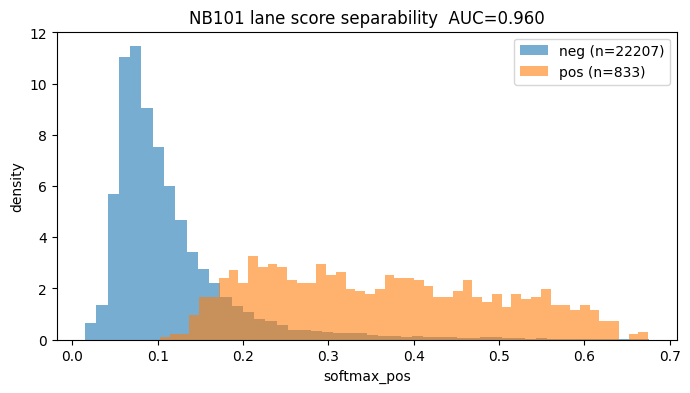

In [5]:
import matplotlib.pyplot as plt

m=load_model(NB101_BEST)
pos, neg, gaps = [], [], []
for st in STEMS[:120]:
    img=cv2.imread(str(VAL/f'{st}.jpg')); pr=raw_rows(m,img); gt=gt_rows(st)
    if gt is None: continue
    sc=lcf1._softmax_pos(pr)
    # which priors match a GT lane (IoU>=0.5)? reuse the metric internals
    gms=[]
    for g in gt:
        gp=lcf1._decode_row(g,160,72,is_pred=False)
        if gp is not None: gms.append(lcf1._rasterize_one(gp,160,12))
    order=np.argsort(-sc)
    matched=set()
    if gms:
        for j in order[:32]:                 # only need to test high-score priors
            pp=lcf1._decode_row(pr[j],160,72,is_pred=True)
            if pp is None: continue
            pm=lcf1._rasterize_one(pp,160,12)
            for gm in gms:
                inter=np.logical_and(pm,gm).sum(); union=pm.sum()+gm.sum()-inter
                if union>0 and inter/union>=0.5: matched.add(j); break
    for j in range(len(sc)):
        (pos if j in matched else neg).append(float(sc[j]))
    s_sorted=np.sort(sc)[::-1]
    if len(s_sorted)>8: gaps.append(float(s_sorted[7]-s_sorted[8]))   # 8th vs 9th

pos=np.array(pos); neg=np.array(neg)
# simple AUC (Mann-Whitney)
def auc(p,n):
    if len(p)==0 or len(n)==0: return float('nan')
    allv=np.concatenate([p,n]); rank=allv.argsort().argsort().astype(float)+1
    return (rank[:len(p)].sum()-len(p)*(len(p)+1)/2)/(len(p)*len(n))
A=auc(pos,neg)
print(f'matched(+): n={len(pos)} mean={pos.mean():.3f}  unmatched(-): n={len(neg)} mean={neg.mean():.3f}')
print(f'separation AUC={A:.3f}   median 8th-vs-9th score gap={np.median(gaps):.4f}')
print('READ: AUC~0.5 = inseparable (threshold cannot work -> S1.3 mandatory). '
      'AUC>0.8 = a threshold helps a lot (S1.1 alone goes far).')
plt.figure(figsize=(8,4))
plt.hist(neg,bins=50,alpha=0.6,label=f'neg (n={len(neg)})',density=True)
plt.hist(pos,bins=50,alpha=0.6,label=f'pos (n={len(pos)})',density=True)
plt.xlabel('softmax_pos'); plt.ylabel('density'); plt.legend()
plt.title(f'NB101 lane score separability  AUC={A:.3f}')
plt.savefig('/content/nb104_s02_score_hist.png',dpi=80); plt.show()


### S0.3 - Threshold sweep (decode-only): how much of "always 8" is decode?

Re-decode NB101 predictions with `score > tau` (cap at 8) for tau in a sweep;
plot precision/recall/F1 and the correlation between predicted-lane-count and
GT-lane-count. Quantifies the free win from S1.1 (thresholded decode) vs what
needs retraining (S1.3).


  tau=0.0  P=0.245 R=0.403 F1=0.305  pred_cnt=8.0 gt_cnt=4.9 cnt_corr=0.000
  tau=0.1  P=0.245 R=0.403 F1=0.305  pred_cnt=8.0 gt_cnt=4.9 cnt_corr=0.000
  tau=0.2  P=0.253 R=0.403 F1=0.311  pred_cnt=7.8 gt_cnt=4.9 cnt_corr=0.387
  tau=0.3  P=0.289 R=0.393 F1=0.333  pred_cnt=6.6 gt_cnt=4.9 cnt_corr=0.636
  tau=0.4  P=0.354 R=0.340 F1=0.346  pred_cnt=4.7 gt_cnt=4.9 cnt_corr=0.606
  tau=0.5  P=0.482 R=0.230 F1=0.311  pred_cnt=2.3 gt_cnt=4.9 cnt_corr=0.530
  tau=0.6  P=0.649 R=0.063 F1=0.116  pred_cnt=0.5 gt_cnt=4.9 cnt_corr=0.277
  tau=0.7  P=0.000 R=0.000 F1=0.000  pred_cnt=0.0 gt_cnt=4.9 cnt_corr=0.000
  tau=0.8  P=0.000 R=0.000 F1=0.000  pred_cnt=0.0 gt_cnt=4.9 cnt_corr=0.000


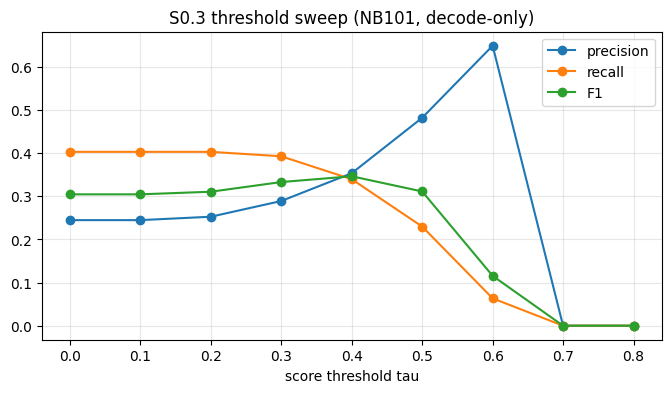


BEST decode-only F1=0.346 at tau=0.4 (vs current 8-lane F1=0.305). If F1 jumps a lot -> S1.1 thresholded decode is a big free win.


In [6]:
import matplotlib.pyplot as plt

m = m if 'm' in globals() else load_model(NB101_BEST)
TAUS=[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
# cache rows once
cache=[]
for st in STEMS[:120]:
    img=cv2.imread(str(VAL/f'{st}.jpg')); pr=raw_rows(m,img); gt=gt_rows(st)
    if gt is None: continue
    cache.append((pr,gt))

def count_gt(gt):
    return int(sum(1 for g in gt if float(g[1])>=0.5))

rows_out=[]
for tau in TAUS:
    TP=FP=FN=0; pc=[]; gc_=[]
    for pr,gt in cache:
        sc=lcf1._softmax_pos(pr)
        keep=np.where(sc>tau)[0]
        keep=keep[np.argsort(-sc[keep])][:8]          # threshold THEN cap at 8
        sub=pr[keep] if len(keep) else pr[:0]
        a,b,c,_,_=lcf1.lane_curve_tp_fp_fn(sub if len(sub) else np.zeros((0,pr.shape[1])), gt)
        TP+=a; FP+=b; FN+=c
        pc.append(len(keep)); gc_.append(count_gt(gt))
    P=TP/(TP+FP) if TP+FP else 0; R=TP/(TP+FN) if TP+FN else 0
    F1=2*P*R/(P+R) if P+R else 0
    corr=float(np.corrcoef(pc,gc_)[0,1]) if np.std(pc)>0 and np.std(gc_)>0 else 0.0
    rows_out.append((tau,P,R,F1,np.mean(pc),np.mean(gc_),corr))
    print(f'  tau={tau:.1f}  P={P:.3f} R={R:.3f} F1={F1:.3f}  pred_cnt={np.mean(pc):.1f} gt_cnt={np.mean(gc_):.1f} cnt_corr={corr:.3f}')

import numpy as _np
arr=_np.array([r[:4] for r in rows_out])
plt.figure(figsize=(8,4))
plt.plot(arr[:,0],arr[:,1],'-o',label='precision'); plt.plot(arr[:,0],arr[:,2],'-o',label='recall')
plt.plot(arr[:,0],arr[:,3],'-o',label='F1'); plt.xlabel('score threshold tau'); plt.legend(); plt.grid(alpha=.3)
plt.title('S0.3 threshold sweep (NB101, decode-only)')
plt.savefig('/content/nb104_s03_threshold.png',dpi=80); plt.show()
best=max(rows_out,key=lambda r:r[3])
print(f'\nBEST decode-only F1={best[3]:.3f} at tau={best[0]:.1f} (vs current 8-lane F1={rows_out[0][3]:.3f}). '
      'If F1 jumps a lot -> S1.1 thresholded decode is a big free win.')


### S0.4 - Near-vs-far jaggedness (the sawtooth you saw in NB103)

For each matched predicted lane, compute the "jaggedness" = mean squared 2nd
difference of x along the lane, split into far-half (top of image) and
near-half (bottom). The plan predicts near >> far. This gives the baseline
number that S1.2 (smoothness reg) must halve.


In [7]:
m = m if 'm' in globals() else load_model(NB101_BEST)

def jag(poly):
    """poly (M,2) sorted by y; return (far_jag, near_jag) mean-sq 2nd-diff of x."""
    if poly is None or len(poly)<5: return None
    p=poly[np.argsort(poly[:,1])]; x=p[:,0].astype(float); y=p[:,1]
    mid=(y.min()+y.max())/2
    out=[]
    for lo,hi in [(y.min(),mid),(mid,y.max())]:
        seg=x[(y>=lo)&(y<=hi)]
        if len(seg)>=3:
            d2=seg[2:]-2*seg[1:-1]+seg[:-2]; out.append(float(np.mean(d2**2)))
        else: out.append(np.nan)
    return out  # [far(top), near(bottom)]

far_all, near_all = [], []
for st in STEMS[:120]:
    img=cv2.imread(str(VAL/f'{st}.jpg')); pr=raw_rows(m,img)
    sc=lcf1._softmax_pos(pr); order=np.argsort(-sc)[:8]
    for j in order:
        poly=lcf1._decode_row(pr[j],S,72,is_pred=True)
        jr=jag(poly)
        if jr is None: continue
        if not np.isnan(jr[0]): far_all.append(jr[0])
        if not np.isnan(jr[1]): near_all.append(jr[1])
far=np.array(far_all); near=np.array(near_all)
fm=np.median(far) if len(far) else float('nan'); nm=np.median(near) if len(near) else float('nan')
print(f'jaggedness (median mean-sq 2nd-diff of x, px^2):')
print(f'  FAR (top half):  {fm:.2f}   (n={len(far)})')
print(f'  NEAR (bottom):   {nm:.2f}   (n={len(near)})')
print(f'  NEAR/FAR ratio:  {nm/fm:.2f}x' if fm and not np.isnan(fm) else '  ratio: n/a')
print('READ: ratio >> 1 CONFIRMS the sawtooth is near-field (your NB103 observation). '
      'This NEAR number is the S1.2 smoothness-reg target (halve it).')


jaggedness (median mean-sq 2nd-diff of x, px^2):
  FAR (top half):  1533.09   (n=832)
  NEAR (bottom):   758.33   (n=835)
  NEAR/FAR ratio:  0.49x
READ: ratio >> 1 CONFIRMS the sawtooth is near-field (your NB103 observation). This NEAR number is the S1.2 smoothness-reg target (halve it).


### Sprint 0 exit summary

Restates the four numbers and the decision they imply, per the plan's Sprint-0
exit criterion.


In [8]:
print('='*70)
print('SPRINT 0 EXIT CRITERION (fill from cells above):')
print('='*70)
print('S0.1  bezier curve-F1 (fixed decoder)  : see Cell S0.1 - was it mis-scored?')
print('S0.2  cls separability AUC             : see Cell S0.2 - threshold-able?')
print('S0.3  best decode-only F1 @ tau        : see Cell S0.3 - free win size?')
print('S0.4  near/far jaggedness ratio        : see Cell S0.4 - sawtooth confirmed?')
print()
print('DECISION (per NEXT_STEPS sec 4):')
print(' - If bezier F1 competitive+smoother -> prioritize Sprint 2 S2.B (re-scored bezier).')
print(' - If AUC~0.5 -> S1.3 (IoU-aware cls) is MANDATORY, threshold alone wont fix cardinality.')
print(' - If decode-only F1 jumps -> S1.1 thresholded decode is a big free win (do first).')
print(' - near/far ratio sets the S1.2 smoothness-reg target.')
print()
print('Next: build NB105 = Sprint 1 ablation grid (threshold / smooth / iou-cls / y-reweight).')


SPRINT 0 EXIT CRITERION (fill from cells above):
S0.1  bezier curve-F1 (fixed decoder)  : see Cell S0.1 - was it mis-scored?
S0.2  cls separability AUC             : see Cell S0.2 - threshold-able?
S0.3  best decode-only F1 @ tau        : see Cell S0.3 - free win size?
S0.4  near/far jaggedness ratio        : see Cell S0.4 - sawtooth confirmed?

DECISION (per NEXT_STEPS sec 4):
 - If bezier F1 competitive+smoother -> prioritize Sprint 2 S2.B (re-scored bezier).
 - If AUC~0.5 -> S1.3 (IoU-aware cls) is MANDATORY, threshold alone wont fix cardinality.
 - If decode-only F1 jumps -> S1.1 thresholded decode is a big free win (do first).
 - near/far ratio sets the S1.2 smoothness-reg target.

Next: build NB105 = Sprint 1 ablation grid (threshold / smooth / iou-cls / y-reweight).
